[*********************100%***********************]  1 of 1 completed


Daily Volatility: 0.81117840422072 %
Annualized Historical Volatility: 12.877057958845514 %


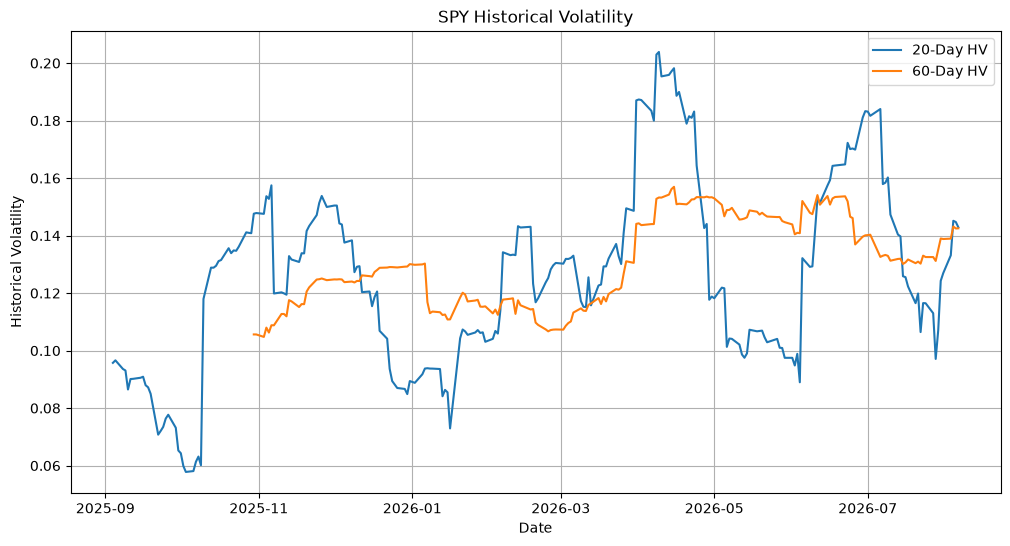

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spy = yf.download("SPY", period="1y", auto_adjust=True)

spy.columns = spy.columns.get_level_values(0)
spy.columns.name = None

spy["Log Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy = spy.dropna()

daily_volatility = spy["Log Return"].std()

print("Daily Volatility:", daily_volatility*100, "%")

annual_hv = daily_volatility * np.sqrt(252)

print("Annualized Historical Volatility:", annual_hv*100, "%")

spy["HV20"] = (
    spy["Log Return"]
    .rolling(window=20)
    .std()
    * np.sqrt(252)
)

spy["HV60"] = (
    spy["Log Return"]
    .rolling(window=60)
    .std()
    * np.sqrt(252)
)

spy[["Close", "HV20", "HV60"]].tail(10)

plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["HV20"], label="20-Day HV")
plt.plot(spy.index, spy["HV60"], label="60-Day HV")

plt.title("SPY Historical Volatility")
plt.xlabel("Date")
plt.ylabel("Historical Volatility")

plt.legend()

plt.grid(True)

plt.show()

spy.to_csv("../data/historical/SPY_HistoricalVolatility.csv")